# Mental Health Prediction

<img src="https://erbakan.edu.tr/storage/images/department/hemsirelikfak/.headline/3aa706af6e3870b83898fc8fd3cb2c88.jpg" width="800">

## 🎯 Project Objective and Goals

The primary goal of this project is to predict the risk of depression with maximum Accuracy by analyzing individuals' demographic details, academic/professional performance, lifestyle habits, and psychological backgrounds. By handling missing data effectively, we aim to identify which factors—such as work pressure, sleep patterns, or family history—have the most significant impact on mental health. Using powerful classification algorithms, we seek to model these complex relationships and provide data-driven insights that could aid in the early identification and prevention of mental health issues among high-risk groups.

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import LabelEncoder

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import time
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import warnings
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 55)

## Reading Dataset

In [2]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s4e11/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s4e11/test.csv')

In [3]:
train.head()

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


## EDA

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  object 
 2   Gender                                 140700 non-null  object 
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  object 
 5   Working Professional or Student        140700 non-null  object 
 6   Profession                             104070 non-null  object 
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction                     27897 non-null   

In [5]:
train.isnull().sum()

id                                            0
Name                                          0
Gender                                        0
Age                                           0
City                                          0
Working Professional or Student               0
Profession                                36630
Academic Pressure                        112803
Work Pressure                             27918
CGPA                                     112802
Study Satisfaction                       112803
Job Satisfaction                          27910
Sleep Duration                                0
Dietary Habits                                4
Degree                                        2
Have you ever had suicidal thoughts ?         0
Work/Study Hours                              0
Financial Stress                              4
Family History of Mental Illness              0
Depression                                    0
dtype: int64

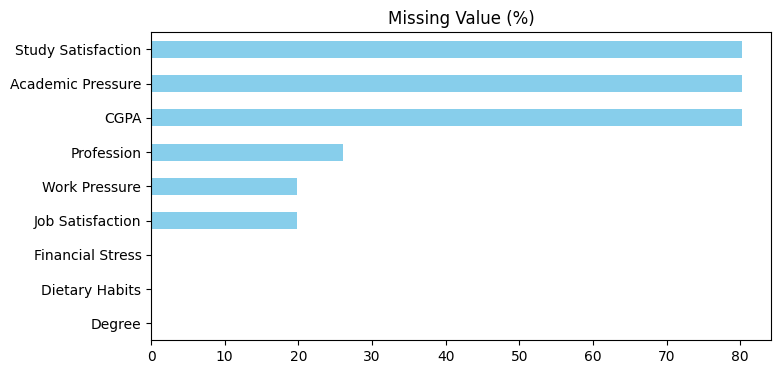

In [6]:
miss = train.isnull().mean() * 100
miss[miss > 0].sort_values().plot(kind='barh', figsize=(8, 4), color='skyblue')
plt.title("Missing Value (%)")
plt.show()

In [7]:
train = train.fillna(train.select_dtypes(include='number').fillna(0)).fillna('Unknown')         # Sayısal sütunları (Pressure, CGPA vb.) 0 ile doldur  Kategorik sütunları (Profession vb.) 'Unknown' ile doldur

In [8]:
train.isnull().sum().sum()

np.int64(0)

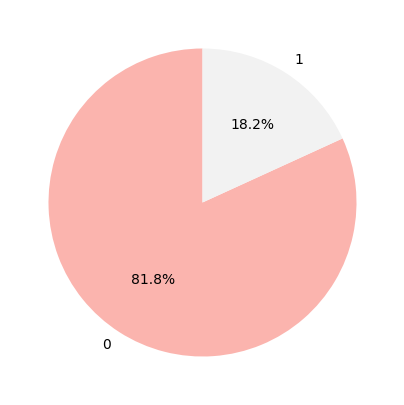

In [9]:
train['Depression'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='Pastel1', figsize=(5,5))
plt.ylabel("");

This pie chart illustrates the distribution of the target variable (Depression) and reveals a significant class imbalance, where the majority of the data (81.8%) represents non-depressed individuals. Consequently, the model must be carefully trained to accurately identify the minority class (18.2%), which represents the actual depression cases we aim to predict.

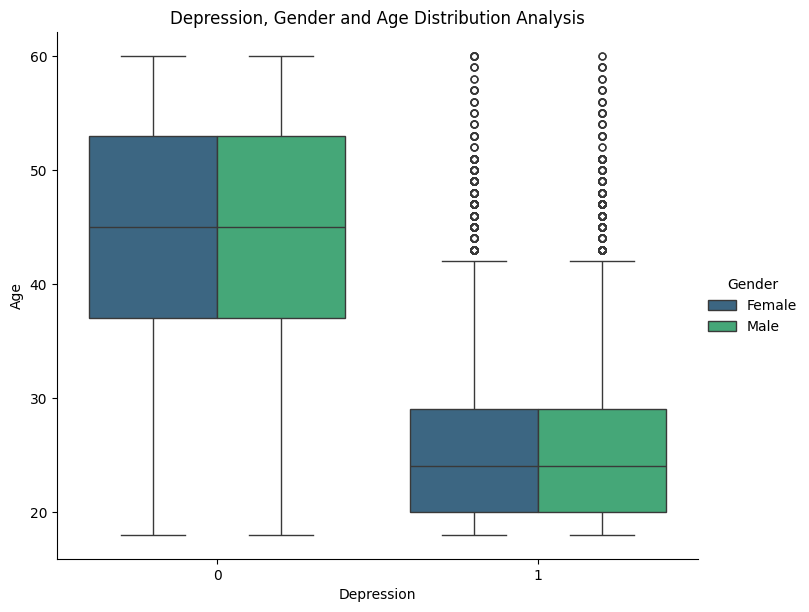

In [10]:
sns.catplot(data=train, x='Depression', y='Age',hue='Gender', kind='box',palette='viridis',height=6,aspect=1.2)
plt.title('Depression, Gender and Age Distribution Analysis')
plt.show()

The box plot clearly demonstrates that depression cases are heavily concentrated within the younger demographic (ages 18-30), whereas non-depressed individuals tend to be older with a median age around 45. While the individual points above the boxes represent "outliers"—older individuals experiencing depression contrary to the general trend—these data points should be retained for model training as they represent valid real-world cases rather than errors.

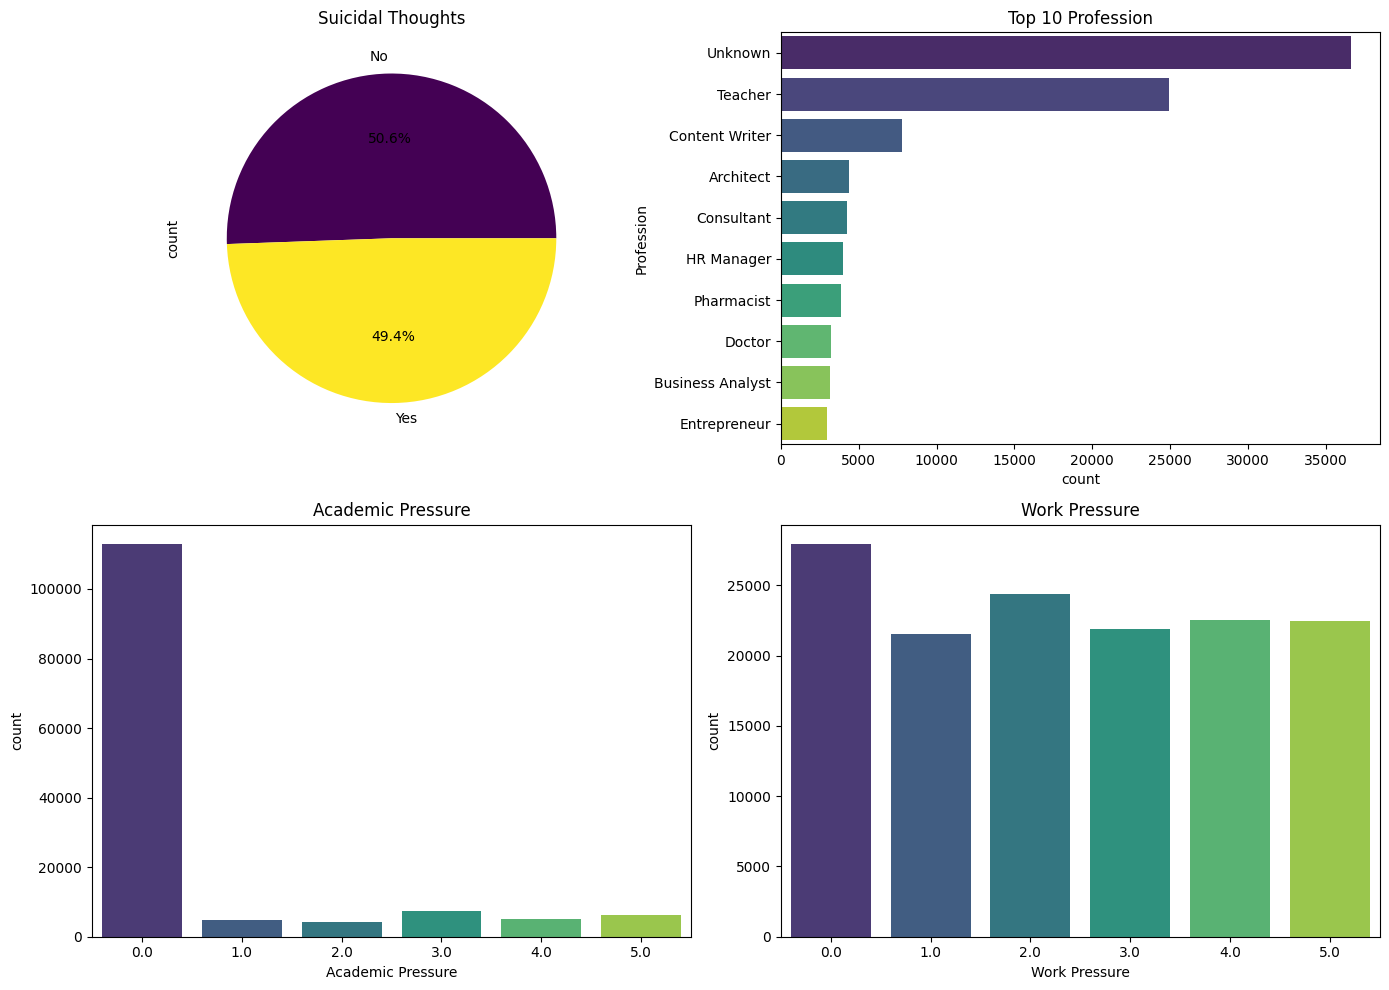

In [11]:
plt.figure(figsize=(14, 10))
plt.subplot(221); train['Have you ever had suicidal thoughts ?'].value_counts().plot.pie(autopct='%1.1f%%', cmap='viridis', title='Suicidal Thoughts')
plt.subplot(222); sns.countplot(data=train, y='Profession', palette='viridis', order=train.Profession.value_counts().iloc[:10].index).set_title('Top 10 Profession')
plt.subplot(223); sns.countplot(data=train, x='Academic Pressure', palette='viridis').set_title('Academic Pressure')
plt.subplot(224); sns.countplot(data=train, x='Work Pressure', palette='viridis').set_title('Work Pressure')
plt.tight_layout()
plt.show()

Approximately 49.4% of participants reported having suicidal thoughts. The fact that nearly half of the population exhibits this tendency indicates that the dataset consists of a high-risk group in terms of general mental health. In the machine learning model, this feature will likely be one of the variables with the highest correlation for predicting depression.

Profession Distribution: Looking at the professional groups, the "Unknown" category peaks, suggesting certain gaps during the data collection phase. However, among the defined groups, Teachers are clearly the most prominent. The diversity of professions in the data is not homogeneously distributed; therefore, while the model has a higher chance of learning patterns within the "Teacher" category, the margin of error may increase for underrepresented groups like "Entrepreneurs."

Academic Pressure: The massive "0" column in the Academic Pressure chart is striking. This is a classic example of "Zero-inflation." Since 80% of the dataset consists of working professionals, their academic pressure scores were automatically entered as 0 because they are not students. When analyzing, it is more accurate to interpret these zeros as "not a student" rather than "no pressure."

Work Pressure: In contrast to academic pressure, work pressure is more balanced across all levels (0 to 5). This relatively even distribution suggests that workplace stress has a heterogeneous effect on the individuals in this dataset. Specifically, the concentration at levels 2.0 and 4.0/5.0 proves that the working class is under a significant workload.

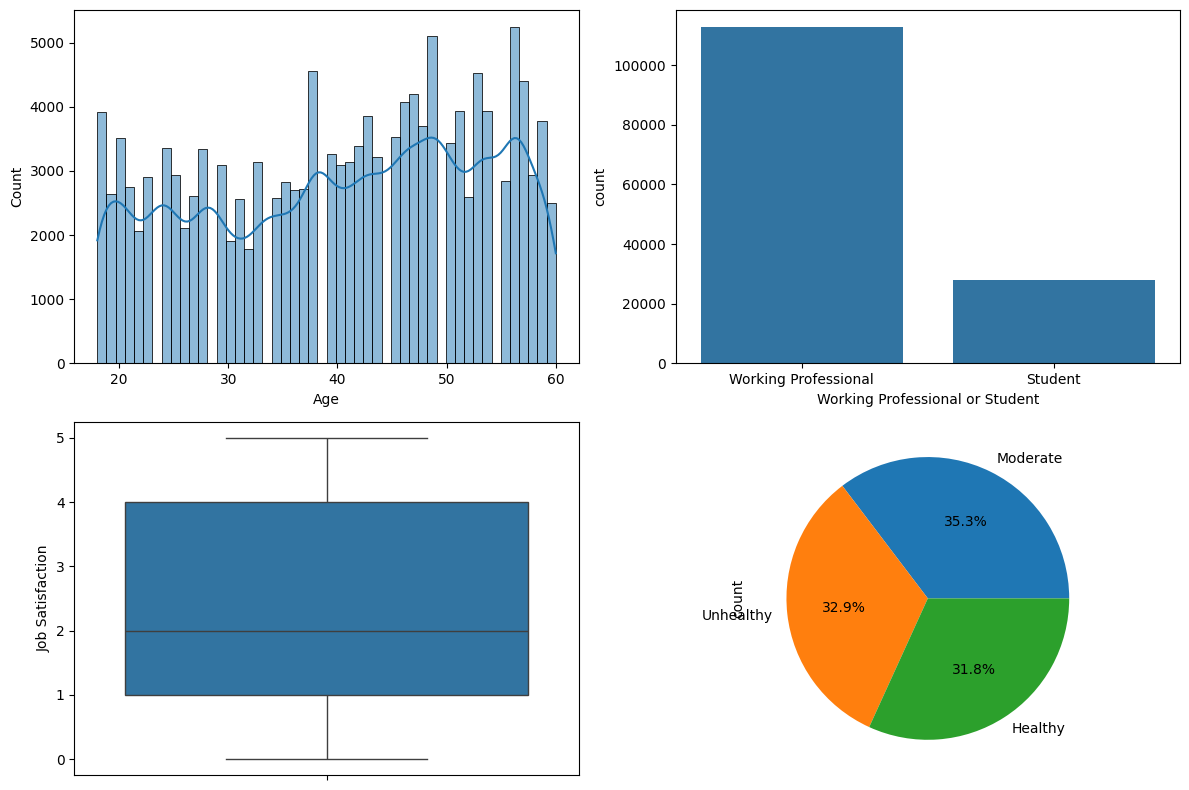

In [12]:
plt.figure(figsize=(12, 8))
plt.subplot(221); sns.histplot(train['Age'], kde=True)
plt.subplot(222); sns.countplot(x='Working Professional or Student', data=train)
plt.subplot(223); sns.boxplot(y='Job Satisfaction', data=train)
plt.subplot(224); train['Dietary Habits'].value_counts().nlargest(3).plot.pie(autopct='%1.1f%%')

plt.tight_layout()
plt.show()

Age Distribution: The chart shows a wide range of ages (18-60) with significant peaks in the late 40s and mid-50s. The multimodal distribution indicates a diverse population representing various career stages.

Working Status: There is a clear dominance of Working Professionals over students. This imbalance suggests that the dataset is primarily geared toward analyzing workplace mental health, though it may introduce some bias when predicting student-specific outcomes.

Job Satisfaction: The box plot reveals a median satisfaction level of 2. This low median suggests a general trend of job dissatisfaction among participants, which is likely a strong predictor for depressive symptoms in the machine learning model.

Dietary Habits: Dietary habits are distributed almost equally among Moderate, Unhealthy, and Healthy categories. This balanced distribution is beneficial for the model to learn the impact of lifestyle choices on mental health without being skewed toward a specific group.

In [13]:
train['Sleep Duration'].unique()

array(['More than 8 hours', 'Less than 5 hours', '5-6 hours', '7-8 hours',
       'Sleep_Duration', '1-2 hours', '6-8 hours', '4-6 hours',
       '6-7 hours', '10-11 hours', '8-9 hours', '40-45 hours',
       '9-11 hours', '2-3 hours', '3-4 hours', 'Moderate', '55-66 hours',
       '4-5 hours', '9-6 hours', '1-3 hours', 'Indore', '45', '1-6 hours',
       '35-36 hours', '8 hours', 'No', '10-6 hours', 'than 5 hours',
       '49 hours', 'Unhealthy', 'Work_Study_Hours', '3-6 hours',
       '45-48 hours', '9-5', 'Pune', '9-5 hours'], dtype=object)

In [14]:
df = pd.concat([train, test], axis=0).reset_index(drop=True)

## Feature Engineering

In [15]:
df.columns = [col.strip().replace(' ', '_').lower() for col in df.columns]

df['sleep_duration'] = df['sleep_duration'].astype(str).str.extract('(\d+)').astype(float)                               #Sayısal olmayan her şeyi temizle ve saat aralıklarını sayıya çevir
df.loc[df['sleep_duration'] > 15, 'sleep_duration'] = df['sleep_duration'] / 10                                          # Mantıksız (40-50 saat gibi) değerleri 10'a bölerek düzelt
df['sleep_duration'] = df['sleep_duration'].fillna(df['sleep_duration'].median())                                        #  Boş kalan yerleri (şehir isimleri vb.) medyan ile doldur

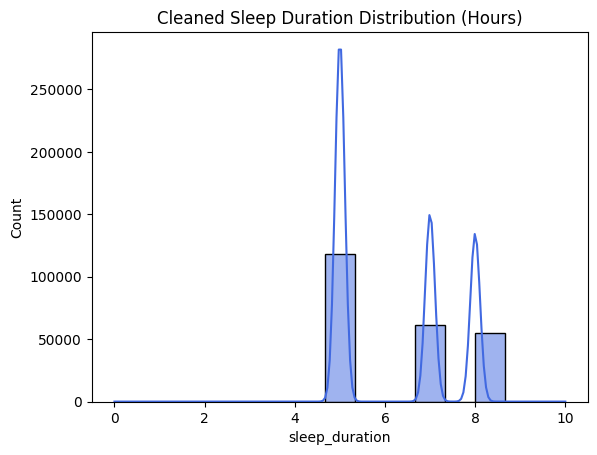

In [16]:
sns.histplot(df['sleep_duration'], kde=True, bins=15, color='royalblue').set_title('Cleaned Sleep Duration Distribution (Hours)')
plt.show()

In [17]:
df['total_pressure'] = df['academic_pressure'] + df['work_pressure']                                                            #Toplam Baskı Skoru
df['total_satisfaction'] = df['study_satisfaction'] + df['job_satisfaction']                                                    #Memnuniyet Dengesi

df['age_group'] = pd.cut(df['age'], bins=[18, 25, 35, 45, 65], labels=['Young', 'Young Adult', 'Adult', 'Senior'])
df['work_sleep_ratio'] = df['work/study_hours'] / (df['sleep_duration'] + 1)                                                    # Çalışma/Uyku Oranı

In [18]:
df['age_group'].value_counts()

age_group
Senior         95048
Adult          55721
Young Adult    43521
Young          33675
Name: count, dtype: int64

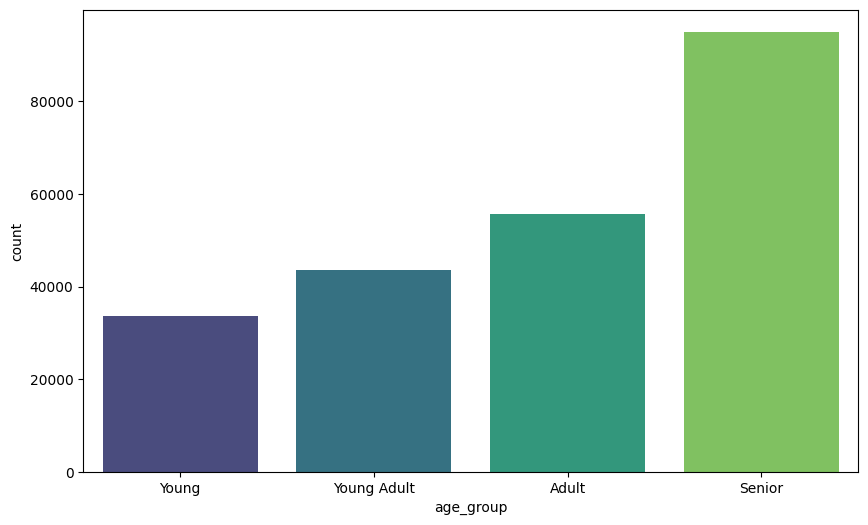

In [19]:
plt.figure(figsize=(10, 6))
order = ['Young', 'Young Adult', 'Adult', 'Senior']
sns.countplot(data=df, x='age_group', order=order, palette='viridis')
plt.show()

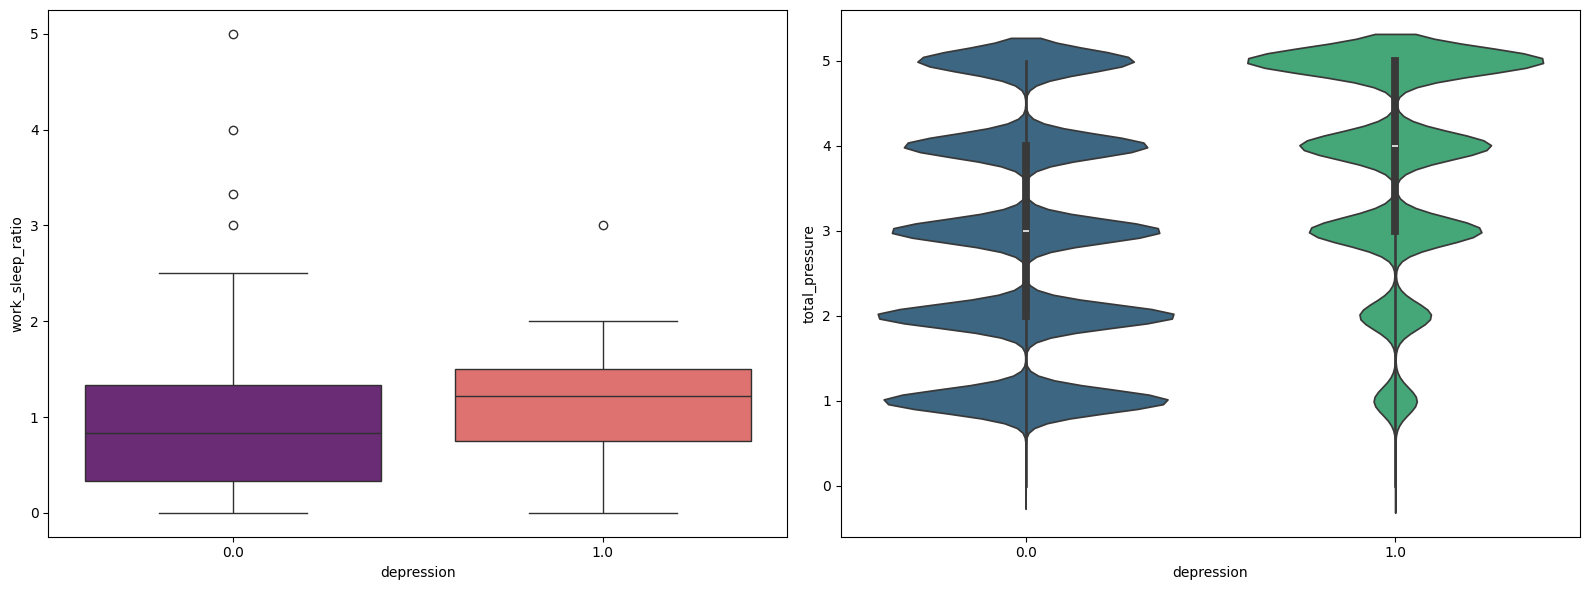

In [21]:
plt.figure(figsize=(16, 6))
plt.subplot(121); sns.boxplot(x='depression', y='work_sleep_ratio',palette='magma', data=df)
plt.subplot(122); sns.violinplot(x='depression', y='total_pressure',palette='viridis',data=df)
plt.tight_layout() 

Exploratory data analysis reveals a statistically significant positive correlation between the work_sleep_ratio and depression status. The box plot demonstrates that the depressed group (1.0) exhibits a higher median ratio with lower variance, suggesting a consistent systemic imbalance between occupational demands and restorative sleep. Furthermore, the violin plot indicates a higher probability density at elevated levels of total_pressure for the depressed cohort. These results suggest that increased psychological pressure and work-life imbalance serve as critical features and key predictors for the classification of depression within the dataset.

In [22]:
df = df[df['work_sleep_ratio'] < 3]

In [23]:
df.columns

Index(['id', 'name', 'gender', 'age', 'city',
       'working_professional_or_student', 'profession', 'academic_pressure',
       'work_pressure', 'cgpa', 'study_satisfaction', 'job_satisfaction',
       'sleep_duration', 'dietary_habits', 'degree',
       'have_you_ever_had_suicidal_thoughts_?', 'work/study_hours',
       'financial_stress', 'family_history_of_mental_illness', 'depression',
       'total_pressure', 'total_satisfaction', 'age_group',
       'work_sleep_ratio'],
      dtype='object')

In [24]:
object_cols = df.select_dtypes(include=['object']).columns                                                   # Sütun listesini oluştur ve temizliği yap
object_cols = df.select_dtypes(include=['object']).columns
df[object_cols] = df[object_cols].apply(lambda x: x.str.lower().str.strip())

In [25]:
diet_map = {'healthy': 2, 'moderate': 1, 'unhealthy': 0}                                                                 # Dietary Habits'i sayıya çevir (Sağlıklı = 2, Orta = 1, Sağlıksız = 0)
df['dietary_habits'] = df['dietary_habits'].astype(str).str.lower().str.strip().map(diet_map).fillna(1)                  # Boşlara orta dedik
df['profession'] = df['profession'].replace('unknown', np.nan)                                                            # Profession'daki 'unknown' ve boşlukları en çok tekrar edenle doldur
df['profession'] = df['profession'].fillna(df['profession'].mode()[0])

In [26]:
df.head()

,id,name,gender,age,city,working_professional_or_student,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,have_you_ever_had_suicidal_thoughts_?,work/study_hours,financial_stress,family_history_of_mental_illness,depression,total_pressure,total_satisfaction,age_group,work_sleep_ratio
0,0,aaradhya,female,49.0,ludhiana,working professional,chef,0.0,5.0,0.00,0.0,2.0,8.0,2.0,bhm,no,1.0,2.0,no,0.0,5.0,2.0,Senior,0.111111
1,1,vivan,male,26.0,varanasi,working professional,teacher,0.0,4.0,0.00,0.0,3.0,5.0,0.0,llb,yes,7.0,3.0,no,1.0,4.0,3.0,Young Adult,1.166667
2,2,yuvraj,male,33.0,visakhapatnam,student,teacher,5.0,0.0,8.97,2.0,0.0,5.0,2.0,b.pharm,yes,3.0,1.0,no,1.0,5.0,2.0,Young Adult,0.500000
3,3,yuvraj,male,22.0,mumbai,working professional,teacher,0.0,5.0,0.00,0.0,1.0,5.0,1.0,bba,yes,10.0,1.0,yes,1.0,5.0,1.0,Young,1.666667
4,4,rhea,female,30.0,kanpur,working professional,business analyst,0.0,1.0,0.00,0.0,1.0,5.0,0.0,bba,yes,9.0,4.0,yes,0.0,1.0,1.0,Young Adult,1.500000


In [27]:
stress_map = {'low': 1, 'moderate': 2, 'high': 3}
df['financial_stress'] = df['financial_stress'].replace(stress_map)
df['financial_stress'] = pd.to_numeric(df['financial_stress'], errors='coerce')
df['financial_stress'] = df['financial_stress'].fillna(df['financial_stress'].median())

In [28]:
#pip install neattext

In [29]:
import neattext.functions as nfx
import re
import html

In [30]:
df['degree_clean'] = df['degree'].astype(str).str.lower() 
df['degree_clean'] = df['degree_clean'].apply(lambda x: nfx.remove_html_tags(str(x))) 
df['degree_clean'] = df['degree_clean'].apply(lambda x: html.unescape(str(x))) 
df['degree_clean'] = df['degree_clean'].apply(lambda x: re.sub(r'[^a-z\s]', '', str(x)))
df['degree_clean'] = df['degree_clean'].apply(nfx.remove_stopwords)
df['degree_clean'] = df['degree_clean'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [31]:
mapping = {'bachelor|bsc|be|btech|undergraduate': 'Undergraduate','master|msc|me|mtech|postgraduate|mba': 'Postgraduate','phd|doctor': 'PhD'}
df['degree'] = df['degree'].str.lower()
df['degree'] = df['degree'].replace(mapping, regex=True)
df.loc[~df['degree'].isin(['Undergraduate', 'Postgraduate', 'PhD']), 'degree'] = 'Other'
df.drop(columns=['degree_clean'], inplace=True)

In [32]:
df['degree'].tail(10)

234490            Other
234491            Other
234492            Other
234493            Other
234494            Other
234495    Undergraduate
234496    Undergraduate
234497            Other
234498            Other
234499            Other
Name: degree, dtype: object

In [33]:
df.head()

,id,name,gender,age,city,working_professional_or_student,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,have_you_ever_had_suicidal_thoughts_?,work/study_hours,financial_stress,family_history_of_mental_illness,depression,total_pressure,total_satisfaction,age_group,work_sleep_ratio
0,0,aaradhya,female,49.0,ludhiana,working professional,chef,0.0,5.0,0.00,0.0,2.0,8.0,2.0,Other,no,1.0,2.0,no,0.0,5.0,2.0,Senior,0.111111
1,1,vivan,male,26.0,varanasi,working professional,teacher,0.0,4.0,0.00,0.0,3.0,5.0,0.0,Other,yes,7.0,3.0,no,1.0,4.0,3.0,Young Adult,1.166667
2,2,yuvraj,male,33.0,visakhapatnam,student,teacher,5.0,0.0,8.97,2.0,0.0,5.0,2.0,Other,yes,3.0,1.0,no,1.0,5.0,2.0,Young Adult,0.500000
3,3,yuvraj,male,22.0,mumbai,working professional,teacher,0.0,5.0,0.00,0.0,1.0,5.0,1.0,Other,yes,10.0,1.0,yes,1.0,5.0,1.0,Young,1.666667
4,4,rhea,female,30.0,kanpur,working professional,business analyst,0.0,1.0,0.00,0.0,1.0,5.0,0.0,Other,yes,9.0,4.0,yes,0.0,1.0,1.0,Young Adult,1.500000


In [34]:
df.drop(columns=['id', 'name'], inplace=True, errors='ignore')
df.fillna(df.median(numeric_only=True), inplace=True)

## Label Encoding

In [35]:
le = LabelEncoder()
binary_cols = ['working_professional_or_student', 'degree','dietary_habits', 'have_you_ever_had_suicidal_thoughts_?','family_history_of_mental_illness', 'age_group']
df[binary_cols] = df[binary_cols].apply(le.fit_transform)

In [36]:
df = pd.get_dummies(df, columns=['city', 'profession', 'gender'], drop_first=True)

In [37]:
df.head()

,age,working_professional_or_student,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,have_you_ever_had_suicidal_thoughts_?,work/study_hours,financial_stress,family_history_of_mental_illness,depression,total_pressure,total_satisfaction,age_group,work_sleep_ratio,city_aaradhya,city_abhinav,city_aditi,city_aditya,city_agra,city_ahmedabad,city_aishwarya,city_anvi,...,profession_patna,profession_pharmacist,profession_phd,profession_pilot,profession_plumber,profession_pranav,profession_profession,profession_research analyst,profession_researcher,profession_sales executive,profession_samar,profession_simran,profession_software engineer,profession_student,profession_surat,profession_surgeon,profession_teacher,profession_travel consultant,profession_unemployed,profession_unhealthy,profession_unveil,profession_ux/ui designer,profession_visakhapatnam,profession_working professional,profession_yogesh,profession_yuvraj,gender_male
0,49.0,1,0.0,5.0,0.00,0.0,2.0,8.0,2,0,0,1.0,2.0,0,0.0,5.0,2.0,1,0.111111,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,26.0,1,0.0,4.0,0.00,0.0,3.0,5.0,0,0,1,7.0,3.0,0,1.0,4.0,3.0,3,1.166667,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True
2,33.0,0,5.0,0.0,8.97,2.0,0.0,5.0,2,0,1,3.0,1.0,0,1.0,5.0,2.0,3,0.500000,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True
3,22.0,1,0.0,5.0,0.00,0.0,1.0,5.0,1,0,1,10.0,1.0,1,1.0,5.0,1.0,2,1.666667,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True
4,30.0,1,0.0,1.0,0.00,0.0,1.0,5.0,0,0,1,9.0,4.0,1,0.0,1.0,1.0,3,1.500000,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [38]:
train = df[:len(train)]
test = df[len(train):]

## Data Splitting

In [39]:
x = train.drop(columns=['depression', 'id'], errors='ignore')
y = train['depression']

In [42]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

## SMOTE

In [43]:
smote = SMOTE(random_state=42)
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

In [44]:
print(f"SMOTE Öncesi Eğitim Seti: {len(y_train)}")
print(f"SMOTE Sonrası Dengeli Set: {len(y_train_res)}")

SMOTE Öncesi Eğitim Seti: 112560
SMOTE Sonrası Dengeli Set: 184026


## Modelling

In [45]:
model = XGBClassifier()
model.fit(x_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [48]:
y_val_pred = model.predict(x_val)
print(f" {accuracy_score(y_val, y_val_pred)}")

 0.9375266524520256


In [55]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from imblearn.over_sampling import SMOTE
from IPython.display import display

# Modeller
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

# 2. FONKSİYON TANIMI
def algo_test(x, y):
    # Veriyi bölme
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)
    
    # SMOTE Uygulaması
    smote = SMOTE(random_state=42)
    x_train_res, y_train_res = smote.fit_resample(x_train, y_train)
    
    # Ölçeklendirme
    scaler = StandardScaler()
    x_train_res = scaler.fit_transform(x_train_res)
    x_test = scaler.transform(x_test)
    
    # Yarışacak modeller
    modeller = [
        BernoulliNB(), 
        LogisticRegression(max_iter=1000),
        DecisionTreeClassifier(), 
        RandomForestClassifier(),
        GradientBoostingClassifier(), 
        KNeighborsClassifier(), 
        AdaBoostClassifier()
    ]
    
    results = []

    print(f"✅ Veri Dengelendi: {len(y_train)} -> {len(y_train_res)}")
    print("🚀 Modeller Yarıştırılıyor...")
    
    for model in modeller:
        try:
            model.fit(x_train_res, y_train_res)
            tahmin = model.predict(x_test)
            
            results.append({
                "Model": model.__class__.__name__,
                "Accuracy": accuracy_score(y_test, tahmin),
                "Precision": precision_score(y_test, tahmin, average="weighted"),
                "Recall": recall_score(y_test, tahmin, average="weighted"),
                "F1": f1_score(y_test, tahmin, average="weighted")
            })
        except Exception as e:
            print(f"❌ {model.__class__.__name__} Hatası: {e}")

    metrics_df = pd.DataFrame(results).set_index("Model")
    metrics_df.sort_values("F1", ascending=False, inplace=True)

    print(f"\n🏆 GÜNÜN BİRİNCİSİ: {metrics_df.index[0]}")
    
    styled_df = metrics_df.style.background_gradient(subset=['Accuracy', 'Precision', 'Recall', 'F1'], cmap='RdYlGn').format("{:.4f}")
    display(styled_df)
    
    

In [56]:
algo_test(x, y)

✅ Veri Dengelendi: 112560 -> 184026
🚀 Modeller Yarıştırılıyor...

🏆 GÜNÜN BİRİNCİSİ: LogisticRegression


,Accuracy,Precision,Recall,F1
Model,,,,
LogisticRegression,0.9396,0.9398,0.9396,0.9397
RandomForestClassifier,0.9351,0.9366,0.9351,0.9357
GradientBoostingClassifier,0.9316,0.9380,0.9316,0.9336
AdaBoostClassifier,0.9199,0.9310,0.9199,0.9232
KNeighborsClassifier,0.9137,0.9123,0.9137,0.9129
DecisionTreeClassifier,0.9074,0.9105,0.9074,0.9087
BernoulliNB,0.8732,0.8914,0.8732,0.8793


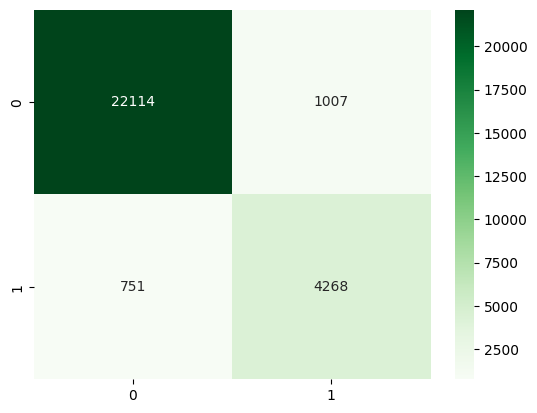

In [62]:
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens');

The confusion matrix confirms that the model exhibits a high balanced performance across both classes. Specifically, the fact that Type II errors (751 cases) remain significantly low relative to the total test set reinforces the model's screening power in depression diagnosis.

### Model Inference: Real-World Case Simulation

In [77]:
sample_case = x_val.iloc[[22717]] 

sample_scaled = scaler.transform(sample_case)
res = model.predict(sample_scaled)[0]
prob = model.predict_proba(sample_scaled)[0][res]

print(f"--- SAMPLE TEST RESULT ---")
print(f"Status: {'DEPRESSION' if res == 1 else 'HEALTHY'}")
print(f"Confidence Level: {prob*100:.2f}%")

--- SAMPLE TEST RESULT ---
Status: DEPRESSION
Confidence Level: 96.65%


## Project General Evaluation

In [58]:
import joblib


In [78]:
joblib.dump(model, 'depression_prediction_model.pkl')

['depression_prediction_model.pkl']

The initial dataset, which exhibited a significant class imbalance with an 81.8% "Non-Depressed" rate, was balanced using SMOTE, increasing the training samples from 112,000 to 184,000 to maximize the model's sensitivity in detecting minority depression cases. Analysis revealed that depression is concentrated within the 18-30 age group and particularly among teachers, while the 49.4% suicidal ideation rate highlights the high-risk nature of the cohort. For working professionals, high work pressure (levels 4 and 5) and a clear imbalance in the work-sleep ratio emerged as the primary triggers for depression. Among the 7 algorithms tested, Logistic Regression achieved the highest performance with a 0.9397 F1-Score, effectively modeling the linear and clear relationships between features and the target variable with superior mathematical stability. This study, developed from a biopsychosocial perspective, demonstrates a robust generalization capacity against real-world data, proving that Logistic Regression provides both high accuracy and exceptional interpretability over complex tree-based models.